In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

import matplotlib.patches as patches

In [4]:
cplot.general()

In [5]:
# Load the data

# n = 0
Real_Eingevalues_rad_polarization_LNn0 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LNn0.npy", allow_pickle=True)
Real_Eingevalues_rad_polarization_LPn0 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LPn0.npy", allow_pickle=True)

Family_rad_polarization_LPn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LPn0.npy", allow_pickle=True)
Family_rad_polarization_LNn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LNn0.npy", allow_pickle=True)

# n = 1
Real_Eingevalues_rad_polarization_LPn1_1 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LPn1_Part1_0_40.npy", allow_pickle=True)
Real_Eingevalues_rad_polarization_LPn1_2 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LPn1_Part2_41_80.npy", allow_pickle=True)
Real_Eingevalues_rad_polarization_LPn1_3 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LPn1_Part3_81_End.npy", allow_pickle=True)

Real_Eingevalues_rad_polarization_LNn1 = np.load("stability_lambda_n_case/Polarization_radial/Real_Eingevalues_rad_polarization_LNn1.npy", allow_pickle=True)

Family_rad_polarization_LPn1 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LPn1.npy", allow_pickle=True)
Family_rad_polarization_LNn1 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_radial_polarization_LNn1.npy", allow_pickle=True)

In [6]:
Real_Eingevalues_rad_polarization_LPn1 = np.append(Real_Eingevalues_rad_polarization_LPn1_1, Real_Eingevalues_rad_polarization_LPn1_2, axis=0)
Real_Eingevalues_rad_polarization_LPn1 = np.append(Real_Eingevalues_rad_polarization_LPn1, Real_Eingevalues_rad_polarization_LPn1_3, axis=0)
len(Real_Eingevalues_rad_polarization_LPn1)

102

In [7]:
import Modules.EnergyMass as en

def find_nearest(array, value):
    n = [abs(i-value) for i in array]
    idx = n.index(min(n))

    indtest = list(array).index(max(array))

    if (indtest != len(array)-1) and (idx < indtest):
        array_test = array[indtest::]
        n = [abs(i-value) for i in array_test]
        idx = n.index(min(n))
        # print('-->', array_test[idx])
        idx = idx + (indtest - 1)

    return (array[idx], idx)

# Checking that all configurations have the same mass up to the first decimal point.
LambT, gamma = [-1, -1], 1
datosTemp = []
datosMasa = []
print('#'*10)
for ind, s0 in enumerate([Family_rad_polarization_LNn0, Family_rad_polarization_LNn1]):
    MT, EnT = 0, 0
    dataTemp, temp = [], []
    for data in s0:
        Ei, rad, sDnew, dsDnew, uDnew, duDnew = data

        #plt.plot(rad, rad * sDnew)
        #plt.xlim(0, 30)
        #plt.show()
        ind2 = rad > 300

        Masa = en.massVal(rad, sDnew**2, gamma=gamma, integrationMetho='simpson') # 'quad')
        arg2 = [LambT[ind], gamma]  # Calculando la masa de la componente
        Enf, _, _ = en.EnFuncion([rad[ind2], sDnew[ind2], None], arg2)  # Calculando la energía de la componente
    
        temp.append([Ei, Masa, sDnew[0]])

        M99 = 0.99 * Masa
        #_, idx = find_nearest(Masa, M99)
        dataTemp.append([sDnew[0], M99])
        
    #print('Masa = %4.1f'%M99)
    datosTemp.append(temp)  # Guardando los datos
    datosMasa.append(dataTemp)
print('#'*10)

##########
##########


In [9]:
massn0 = np.array(datosMasa[0])
massn1 = np.array(datosMasa[1])

sigMaxn0 = massn0[massn0[:, 1].argmax(), 0]
sigMaxn1 = massn1[massn1[:, 1].argmax(), 0]

sigMaxn0, sigMaxn1

(1.5, 7.2)

In [10]:
# n = 0
s0 = Family_rad_polarization_LPn0
s0M = Family_rad_polarization_LNn0

s0P_s0, s0M_s0 = [], []
for cont0, conf in enumerate([s0, s0M]):  #s0M s0
    for cont, s in enumerate(conf):
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        if cont0==0:
            s0P_s0.append(sDnew[0])
        else:
            s0M_s0.append(sDnew[0])

In [11]:
# n = 1
s0 = Family_rad_polarization_LPn1
s0M = Family_rad_polarization_LNn1

n1s0P_s0, n1s0M_s0 = [], []
for cont0, conf in enumerate([s0, s0M]):  #s0M s0
    for cont, s in enumerate(conf):
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        if cont0==0:
            n1s0P_s0.append(sDnew[0])
        else:
            n1s0M_s0.append(sDnew[0])

In [12]:
# Filtrando datos
from collections import defaultdict

def dividir_ramas(datos):
    ramas = defaultdict(list)

    # Agrupar por x
    grupos = defaultdict(list)
    for x, y in datos:
        grupos[x].append(y)

    # Ordenar y asignar a ramas
    for x in sorted(grupos.keys()):  # mantiene orden creciente en x
        # ys = sorted([y for y in grupos[x] if y is not None], reverse=True)
        ys = sorted(grupos[x], reverse=True)  # mayor a menor
        for idx, y in enumerate(ys):
            ramas[idx].append([x, y])

    # Convertir a lista de listas
    return [ramas[k] for k in sorted(ramas.keys())]

Text(0.71, -0.015, 'stable band')

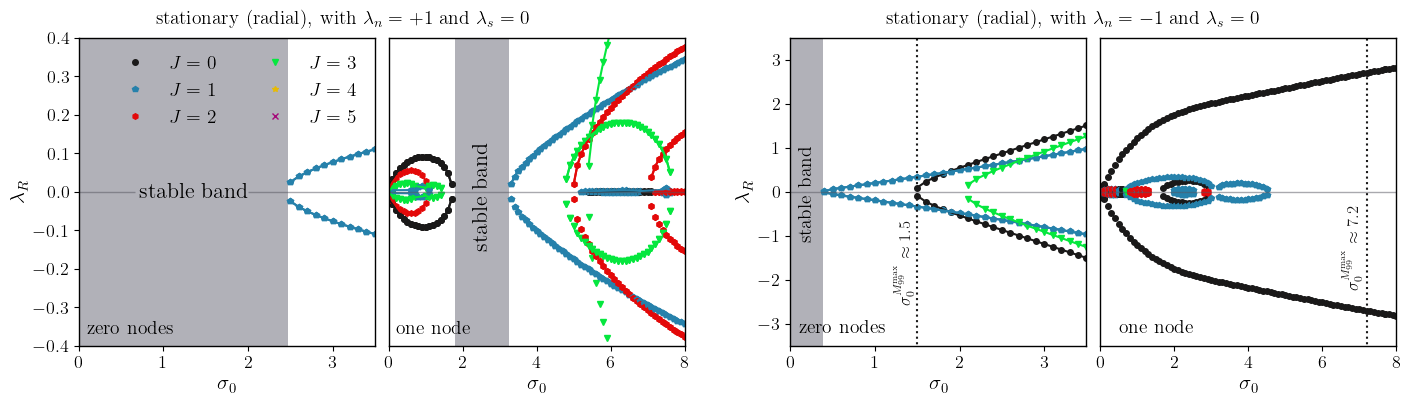

In [23]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

# [Jval_temp, s0, r, eingVal, eigVect]
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LPn0):
      dtemp = []
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 5e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            s0 = s0P_s0[cont]
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

ax[0].legend(frameon=False, fontsize=14, ncols=2)
for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[0].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[0].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[1].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])
    
############################################################

tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LPn1[:50]):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 2e-05 # filtrando los autovalores reales
            y = eingVal[ind]
            s0 = n1s0P_s0[cont]
            x = [s0] * len(y)

            if cont == 0:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[1].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[1].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[1].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LPn1[50:], start=50):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-05 # filtrando los autovalores reales
            y = eingVal[ind]
            s0 = n1s0P_s0[cont]
            x = [s0] * len(y)

            if cont == 0:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[1].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        #arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        #ax[1].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[1].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

ax[1].axvspan(1.8, 3.25, facecolor='#656473', alpha=0.5)
ax[1].text(2.23, -.145, s=r'stable band', rotation='vertical')
    
############################################################

tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            #print(Jval_temp, '-> ', eingVal)
            if Jval_temp == 0 or Jval_temp == 2:
                  ind = np.abs(np.real(eingVal)) >= 8e-05 # filtrando los autovalores reales
                  #print(ind)
                  y = eingVal[ind]
                  s0 = s0M_s0[cont]
                  x = [s0] * len(y)
            else:
                  ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
                  y = eingVal[ind]
                  s0 = s0M_s0[cont]
                  x = [s0] * len(y)
            #print(x, y)
            if cont == 0:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[2].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        ax[2].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])


ax[2].vlines(x=sigMaxn0, ymin=-16, ymax=15, ls=':', lw=1.5, color=col[0])
ax[2].text(x=1.22, y=-2.5, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx %2.1f$'%sigMaxn0, color=col[0], rotation=90, fontsize=12, zorder=10)

############################################################

for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LNn1[:100]):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
            y = eingVal[ind]
            s0 = n1s0M_s0[cont]
            x = [s0] * len(y)
            #print(x, y)
            if cont == 0:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  if Jval_temp == 1 and s0 > 5:
                       continue 
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]

tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for cont, dataExtra in enumerate(Real_Eingevalues_rad_polarization_LNn1[99:], start=99):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
            y = eingVal[ind]
            s0 = n1s0M_s0[cont]
            x = [s0] * len(y)
            #print(x, y)
            if cont == 0:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:                      
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[3].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        ax[3].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

ax[3].vlines(x=sigMaxn1, ymin=-6, ymax=6, ls=':', lw=1.5, color=col[0])
ax[3].text(x=sigMaxn1 - .7, y=-2.15, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx %2.1f$'%sigMaxn1, color=col[0], rotation=90, fontsize=12, zorder=10)

##########
ax[2].axvspan(0, .38, facecolor='#656473', alpha=0.5)
ax[2].text(.08, -1.08, s=r'stable band', rotation='vertical', fontsize=14)

ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')

# Añadir un marco exterior
rectIzq = patches.Rectangle(
    (0.075, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.413,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,  #'#55555e'
    facecolor="none",
    transform=fig.transFigure,
    zorder=10
)

rectDerec = patches.Rectangle(
    (0.495, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.412,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,
    facecolor='none',
    transform=fig.transFigure,
    zorder=10
)

#fig.patches.append(rectIzq)
#fig.patches.append(rectDerec)

# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= + 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

fig.text(
    x=0.71, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= - 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.018, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.018, pos3.y0, pos3.width, pos3.height])

for axes in ax[:2]:
    axes.set_ylim(-.4, .4)
    axes.set_xlabel(r'$\sigma_0$')

for axes in ax[2:]:
    axes.set_ylim(-3.5, 3.5)
    axes.set_xlabel(r'$\sigma_0$')


ax[0].hlines(y=0, xmin=0, xmax=0.66, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[0].hlines(y=0, xmin=2., xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[1].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[2].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[3].hlines(y=0, xmin=0, xmax=50, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[0].set_xlim(0, s0P_s0[-1])
ax[1].set_xlim(0, n1s0P_s0[-1])
ax[2].set_xlim(0, s0M_s0[-1])
ax[3].set_xlim(0, 8) #n1s0M_s0[-1]

ax[0].text(x=0.1, y=-0.37, s=r'zero nodes', fontsize=14)
ax[2].text(x=0.1, y=-3.2, s=r'zero nodes', fontsize=14)
ax[1].text(x=0.2, y=-0.37, s=r'one node', fontsize=14)
ax[3].text(x=0.5, y=-3.2, s=r'one node', fontsize=14)

ax[0].axvspan(0, 2.47, facecolor='#656473', alpha=0.5)
ax[0].text(.71, -0.015, s=r'stable band', rotation='horizontal')

In [24]:
fig.savefig('stationary_radial_lambda.pdf', format='pdf', metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )